# Семантическая сегментация деталей трубопроводной арматуры по LiDAR

Проект: интеллектуальная сегментация деталей трубопроводной арматуры по данным виртуального наземного лазерного сканирования.

**Задача:** для каждой точки облака предсказать класс конструктивного элемента (корпус, фланцы, болты, гайки и т.д.).

**Архитектуры:** PointNet, PointNet++, DGCNN.

**Метрики:** Overall Accuracy, mIoU, Per-class IoU, F1-score, Confusion Matrix.

**Разделение выборки:** 70/15/15 по объектам (не по точкам).


## 1. Подготовка окружения



In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

!pip install -q plyfile


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.4 MB/s eta 0:00:00


In [ ]:
import os
import sys
import json
import random
import time
import shutil
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict

import numpy as np
import matplotlib
matplotlib.use('Agg' if not hasattr(sys, 'ps1') else matplotlib.get_backend())
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from plyfile import PlyData


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
print('PyTorch:', torch.__version__)


Device: cuda
GPU: Tesla T4
PyTorch: 2.11.0+cu128


In [ ]:

DATA_DIR = '/content/drive/MyDrive/16'
RESULTS_ROOT = '/content/drive/MyDrive'


RUN_NAME = '2lidar_valve_seg_' + datetime.now().strftime('%Y%m%d_%H%M%S')
RESULTS_DIR = Path(RESULTS_ROOT) / RUN_NAME
PLOTS_DIR = RESULTS_DIR / 'plots'
MODELS_DIR = RESULTS_DIR / 'models'
METRICS_DIR = RESULTS_DIR / 'metrics'
for d in (RESULTS_DIR, PLOTS_DIR, MODELS_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'seed': SEED,
    'num_points': 2048,
    'batch_size': 16,
    'num_epochs': 50,
    'use_class_weights': True,
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'split_ratios': (0.70, 0.15, 0.15),
    'data_dir': DATA_DIR,
    'results_dir': str(RESULTS_DIR),
    'device': str(device),
    'torch_version': torch.__version__,
}


with open(RESULTS_DIR / 'config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2, ensure_ascii=False)

print('Папка результатов:', RESULTS_DIR)
print('Конфигурация:')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')


Папка результатов: /content/drive/MyDrive/2lidar_valve_seg_20260531_201005
Конфигурация:
  seed: 42
  num_points: 2048
  batch_size: 16
  num_epochs: 50
  use_class_weights: True
  lr: 0.001
  weight_decay: 0.0001
  split_ratios: (0.7, 0.15, 0.15)
  data_dir: /content/drive/MyDrive/16
  results_dir: /content/drive/MyDrive/2lidar_valve_seg_20260531_201005
  device: cuda
  torch_version: 2.11.0+cu128


In [ ]:

ply_files = sorted([str(p) for p in Path(DATA_DIR).glob('*.ply')])
print(f'Найдено файлов: {len(ply_files)}')
print('Первые 5:')
for p in ply_files[:5]:
    print(' ', p)


Найдено файлов: 500
Первые 5:
  /content/drive/MyDrive/16/valve_0001_lidar_classes.ply
  /content/drive/MyDrive/16/valve_0002_lidar_classes.ply
  /content/drive/MyDrive/16/valve_0003_lidar_classes.ply
  /content/drive/MyDrive/16/valve_0004_lidar_classes.ply
  /content/drive/MyDrive/16/valve_0005_lidar_classes.ply


In [ ]:
def read_ply(path):
    '''Читает .ply и возвращает (xyz, labels) как np.ndarray.
    Ищет поле scalar_Label или label среди свойств.'''
    plydata = PlyData.read(path)
    vertex = plydata['vertex']
    xyz = np.stack([vertex['x'], vertex['y'], vertex['z']], axis=1).astype(np.float32)
    label_keys = ['scalar_Label', 'label', 'class', 'scalar_label', 'Label']
    labels = None
    available = vertex.data.dtype.names
    for k in label_keys:
        if k in available:
            labels = np.asarray(vertex[k]).astype(np.int64)
            break
    if labels is None:
        raise KeyError(f'No label field in {path}. Available: {available}')
    return xyz, labels


xyz_test, lab_test = read_ply(ply_files[0])
print('Пример:', ply_files[0])
print('  shape xyz :', xyz_test.shape)
print('  shape lab :', lab_test.shape)
print('  unique lbl:', np.unique(lab_test))
print('  bbox     :', xyz_test.min(0), '->', xyz_test.max(0))


Пример: /content/drive/MyDrive/16/valve_0001_lidar_classes.ply
  shape xyz : (6757, 3)
  shape lab : (6757,)
  unique lbl: [0 1 2 3 4 5 6 7 8 9]
  bbox     : [-151.86215   -55.155052  -50.995323] -> [231.98625 146.69563  83.33647]


In [ ]:

n_points_list = []
classes_per_obj = []
global_label_counter = Counter()
bbox_sizes = []
n_classes_per_obj = []

for i, p in enumerate(ply_files):
    xyz, lab = read_ply(p)
    n_points_list.append(len(xyz))
    uniq = np.unique(lab)
    n_classes_per_obj.append(len(uniq))
    classes_per_obj.append(uniq.tolist())
    global_label_counter.update(lab.tolist())
    bbox_sizes.append((xyz.max(0) - xyz.min(0)).tolist())
    if (i + 1) % 50 == 0:
        print(f'  обработано {i+1}/{len(ply_files)}')

n_points_arr = np.array(n_points_list)
n_classes_arr = np.array(n_classes_per_obj)
bbox_arr = np.array(bbox_sizes)

global_classes = sorted(global_label_counter.keys())
NUM_CLASSES = max(global_classes) + 1   # на случай если есть пропуски

print('\\n=== Статистика датасета ===')
print(f'Объектов               : {len(ply_files)}')
print(f'Точек на облако (мин)  : {n_points_arr.min()}')
print(f'Точек на облако (макс) : {n_points_arr.max()}')
print(f'Точек на облако (сред) : {n_points_arr.mean():.0f}')
print(f'Точек на облако (медиана): {np.median(n_points_arr):.0f}')
print(f'Уникальных классов     : {len(global_classes)}  (макс id = {max(global_classes)})')
print(f'Классов на объект (сред): {n_classes_arr.mean():.2f}')
print(f'Классов на объект (мин/макс): {n_classes_arr.min()} / {n_classes_arr.max()}')
print(f'NUM_CLASSES (для модели): {NUM_CLASSES}')
print('\\nГлобальное распределение классов (top по числу точек):')
total_points = sum(global_label_counter.values())
for cls, cnt in sorted(global_label_counter.items()):
    print(f'  class {cls:>3}: {cnt:>10}  ({100*cnt/total_points:.2f}%)')


  обработано 50/500
  обработано 100/500
  обработано 150/500
  обработано 200/500
  обработано 250/500
  обработано 300/500
  обработано 350/500
  обработано 400/500
  обработано 450/500
  обработано 500/500
\n=== Статистика датасета ===
Объектов               : 500
Точек на облако (мин)  : 6297
Точек на облако (макс) : 8703
Точек на облако (сред) : 7383
Точек на облако (медиана): 7360
Уникальных классов     : 10  (макс id = 9)
Классов на объект (сред): 10.00
Классов на объект (мин/макс): 10 / 10
NUM_CLASSES (для модели): 10
\nГлобальное распределение классов (top по числу точек):
  class   0:     340012  (9.21%)
  class   1:      87023  (2.36%)
  class   2:      39581  (1.07%)
  class   3:     321175  (8.70%)
  class   4:      41552  (1.13%)
  class   5:     513526  (13.91%)
  class   6:     296729  (8.04%)
  class   7:     218787  (5.93%)
  class   8:     359673  (9.74%)
  class   9:    1473281  (39.91%)


In [ ]:

df_stats = pd.DataFrame({
    'file': [Path(p).name for p in ply_files],
    'n_points': n_points_list,
    'n_classes': n_classes_per_obj,
    'bbox_dx': bbox_arr[:, 0],
    'bbox_dy': bbox_arr[:, 1],
    'bbox_dz': bbox_arr[:, 2],
})
df_stats.to_csv(METRICS_DIR / 'dataset_stats.csv', index=False)
with open(METRICS_DIR / 'class_distribution.json', 'w') as f:
    json.dump({str(k): int(v) for k, v in global_label_counter.items()}, f, indent=2)
print('Сохранено: dataset_stats.csv, class_distribution.json')
df_stats.head()


Сохранено: dataset_stats.csv, class_distribution.json


,file,n_points,n_classes,bbox_dx,bbox_dy,bbox_dz
0,valve_0001_lidar_classes.ply,6757,10,383.848389,201.850677,134.331787
1,valve_0002_lidar_classes.ply,7022,10,367.825073,194.913116,175.869385
2,valve_0003_lidar_classes.ply,7650,10,302.077515,193.699615,288.947998
3,valve_0004_lidar_classes.ply,7126,10,311.565094,192.634064,243.947998
4,valve_0005_lidar_classes.ply,7028,10,358.104553,194.779205,195.309723


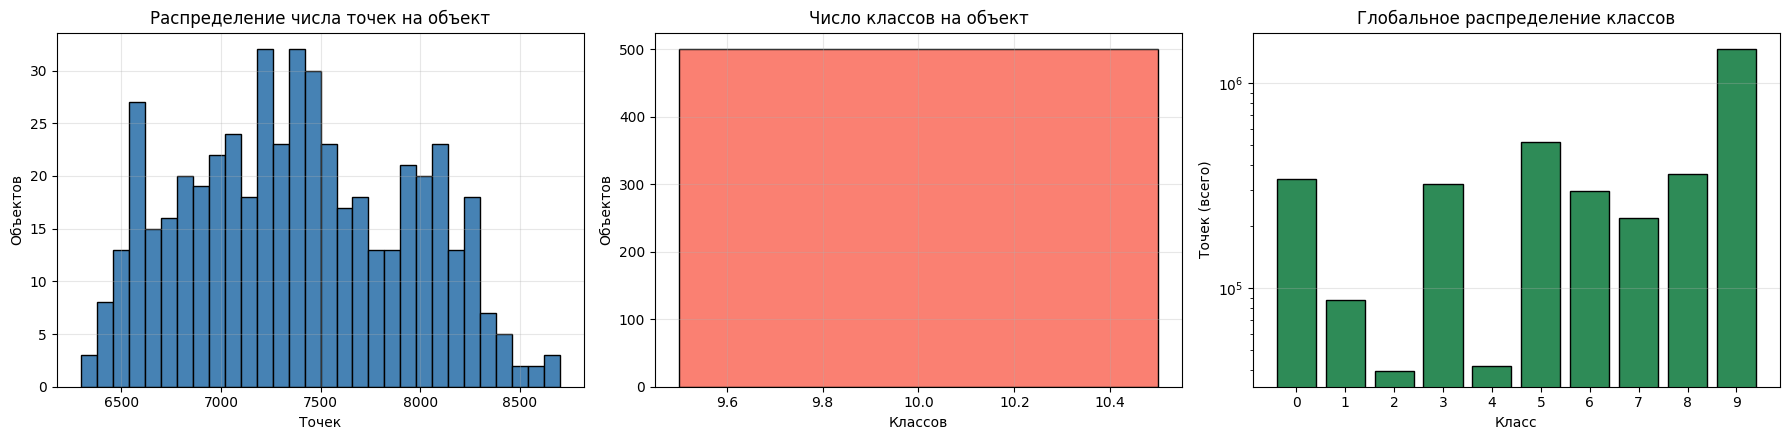

Сохранён график: /content/drive/MyDrive/2lidar_valve_seg_20260531_201005/plots/01_dataset_distributions.png


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].hist(n_points_list, bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Распределение числа точек на объект')
axes[0].set_xlabel('Точек')
axes[0].set_ylabel('Объектов')
axes[0].grid(alpha=0.3)

axes[1].hist(n_classes_per_obj, bins=range(min(n_classes_per_obj), max(n_classes_per_obj)+2),
             color='salmon', edgecolor='black', align='left')
axes[1].set_title('Число классов на объект')
axes[1].set_xlabel('Классов')
axes[1].set_ylabel('Объектов')
axes[1].grid(alpha=0.3)

cls_ids = sorted(global_label_counter.keys())
cls_counts = [global_label_counter[c] for c in cls_ids]
axes[2].bar([str(c) for c in cls_ids], cls_counts, color='seagreen', edgecolor='black')
axes[2].set_title('Глобальное распределение классов')
axes[2].set_xlabel('Класс')
axes[2].set_ylabel('Точек (всего)')
axes[2].set_yscale('log')
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_dataset_distributions.png', dpi=130, bbox_inches='tight')
plt.show()
print('Сохранён график:', PLOTS_DIR / '01_dataset_distributions.png')


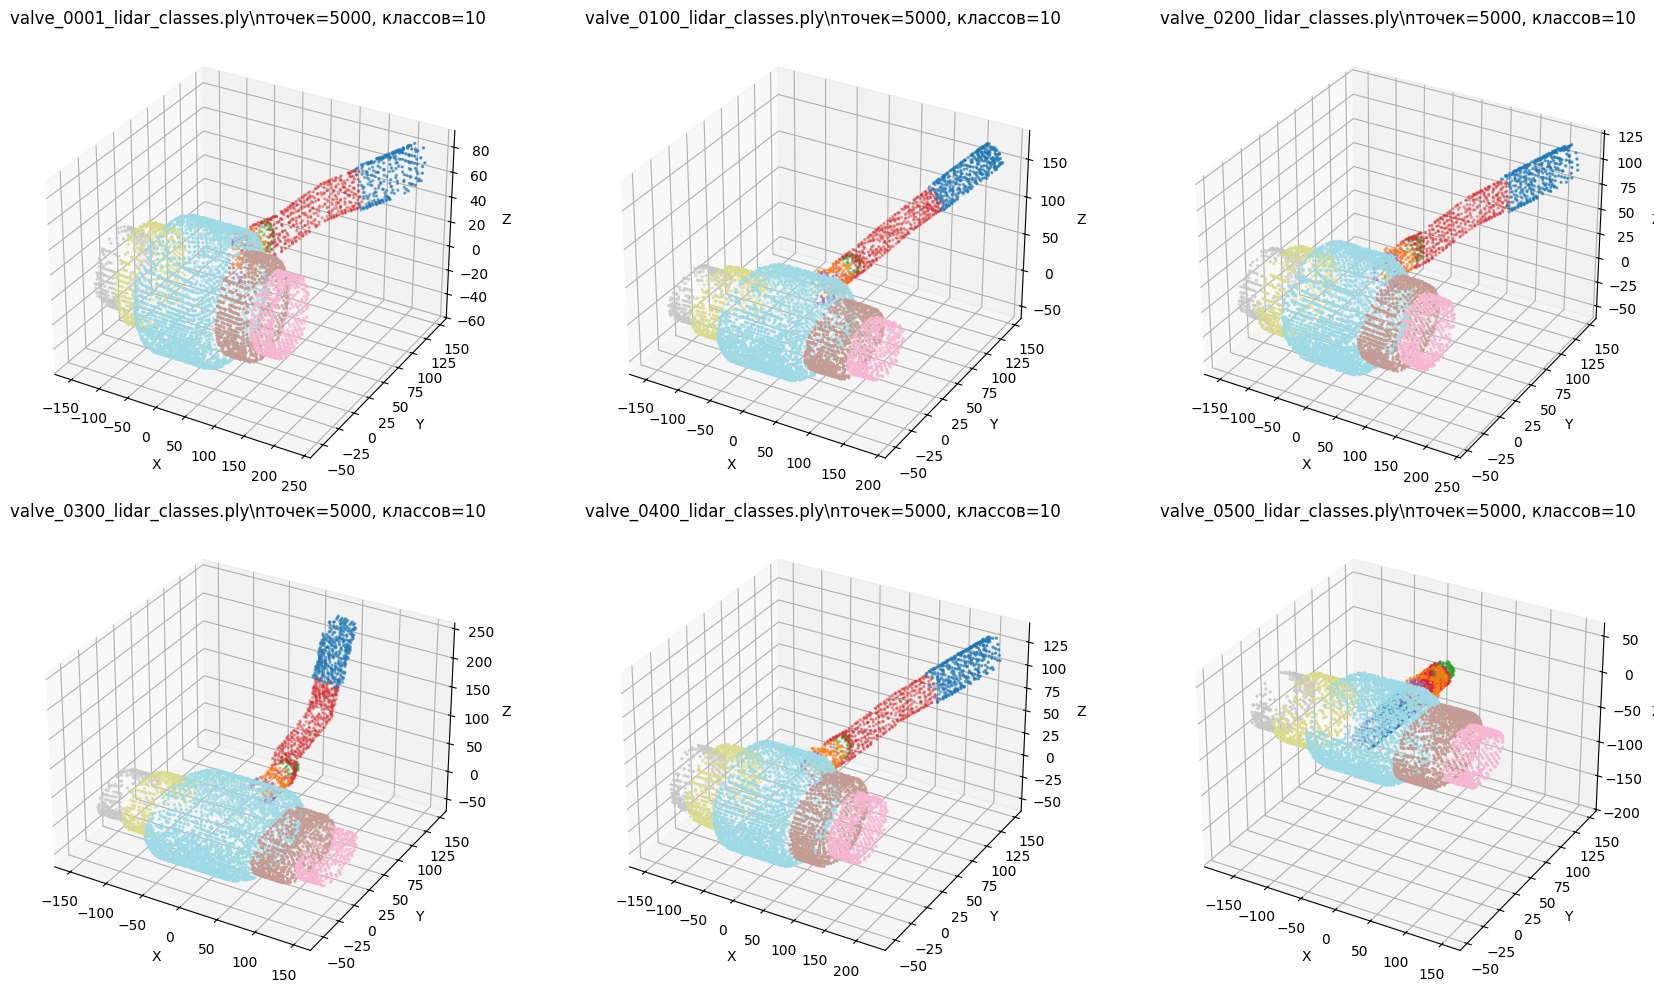

Сохранён график: /content/drive/MyDrive/2lidar_valve_seg_20260531_201005/plots/02_sample_clouds.png


In [ ]:

import matplotlib.cm as cm

sample_idx = np.linspace(0, len(ply_files) - 1, 6).astype(int)
fig = plt.figure(figsize=(18, 10))
for i, idx in enumerate(sample_idx):
    xyz, lab = read_ply(ply_files[idx])

    if len(xyz) > 5000:
        sub = np.random.choice(len(xyz), 5000, replace=False)
        xyz, lab = xyz[sub], lab[sub]
    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    sc = ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], c=lab, cmap='tab20', s=2)
    ax.set_title(f'{Path(ply_files[idx]).name}\\nточек={len(xyz)}, классов={len(np.unique(lab))}')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_sample_clouds.png', dpi=130, bbox_inches='tight')
plt.show()
print('Сохранён график:', PLOTS_DIR / '02_sample_clouds.png')


## 3. Подготовка данных

Делим список объектов на train/val/test (70/15/15) по файлам.

Внутри `Dataset` облако нормализуется (центрирование + масштаб в единичную сферу) и из него сэмплируется фиксированное число точек.


In [ ]:
def normalize_pc(xyz):
    '''Центрируем и масштабируем в единичную сферу.'''
    centroid = xyz.mean(axis=0)
    xyz = xyz - centroid
    scale = np.max(np.linalg.norm(xyz, axis=1))
    if scale > 1e-8:
        xyz = xyz / scale
    return xyz

def sample_points(xyz, labels, n_target):
    '''С повторами если точек меньше нужного, без повторов иначе.'''
    n = len(xyz)
    if n >= n_target:
        idx = np.random.choice(n, n_target, replace=False)
    else:
        idx = np.random.choice(n, n_target, replace=True)
    return xyz[idx], labels[idx]


class ValveDataset(Dataset):
    def __init__(self, file_list, num_points, augment=False):
        self.files = file_list
        self.num_points = num_points
        self.augment = augment

        self._cache = []
        for p in self.files:
            xyz, lab = read_ply(p)
            self._cache.append((xyz, lab))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        xyz, lab = self._cache[idx]
        xyz, lab = sample_points(xyz, lab, self.num_points)
        xyz = normalize_pc(xyz).astype(np.float32)

        if self.augment:
            # Случайный поворот вокруг оси Z (вертикальная ось арматуры)
            theta = np.random.uniform(0, 2 * np.pi)
            R = np.array([[np.cos(theta), -np.sin(theta), 0],
                          [np.sin(theta),  np.cos(theta), 0],
                          [0, 0, 1]], dtype=np.float32)
            xyz = xyz @ R.T
            # Случайное масштабирование (объект может быть чуть крупнее/мельче)
            scale = np.random.uniform(0.85, 1.15)
            xyz = xyz * scale
            # Лёгкое гауссовское дрожание (имитация шума LiDAR)
            xyz = xyz + np.random.normal(0, 0.01, xyz.shape).astype(np.float32)
            # Случайный dropout точек (имитация окклюзии): часть точек "тянем" к центроиду
            drop_ratio = np.random.uniform(0.0, 0.15)
            n_drop = int(self.num_points * drop_ratio)
            if n_drop > 0:
                drop_idx = np.random.choice(self.num_points, n_drop, replace=False)
                # Заменяем выпавшие точки на копии первой точки облака
                xyz[drop_idx] = xyz[0]
                lab[drop_idx] = lab[0]

        # (3, N) для удобства Conv1d
        xyz_t = torch.from_numpy(xyz.T)
        lab_t = torch.from_numpy(lab.astype(np.int64))
        return xyz_t, lab_t


In [ ]:

rng = np.random.RandomState(SEED)
indices = np.arange(len(ply_files))
rng.shuffle(indices)

n_total = len(ply_files)
n_train = int(CONFIG['split_ratios'][0] * n_total)
n_val   = int(CONFIG['split_ratios'][1] * n_total)
n_test  = n_total - n_train - n_val

train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

train_files = [ply_files[i] for i in train_idx]
val_files   = [ply_files[i] for i in val_idx]
test_files  = [ply_files[i] for i in test_idx]

print(f'train: {len(train_files)} | val: {len(val_files)} | test: {len(test_files)}')


splits = {
    'train': [Path(p).name for p in train_files],
    'val':   [Path(p).name for p in val_files],
    'test':  [Path(p).name for p in test_files],
}
with open(METRICS_DIR / 'splits.json', 'w') as f:
    json.dump(splits, f, indent=2)


train: 350 | val: 75 | test: 75


In [ ]:
NUM_POINTS = CONFIG['num_points']
BATCH = CONFIG['batch_size']

train_ds = ValveDataset(train_files, NUM_POINTS, augment=True)
val_ds   = ValveDataset(val_files,   NUM_POINTS, augment=False)
test_ds  = ValveDataset(test_files,  NUM_POINTS, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2)

xb, yb = next(iter(train_loader))
print('Батч xb:', xb.shape, ' yb:', yb.shape, ' dtype:', xb.dtype, yb.dtype)


Батч xb: torch.Size([16, 3, 2048])  yb: torch.Size([16, 2048])  dtype: torch.float32 torch.int64


In [ ]:
# === Class weights по training set (median frequency balancing) ===
# Идея: w_c = median(freq) / freq_c — редкие классы получают вес > 1,
# доминирующие < 1. В отличие от 1/freq, такой вес ограничен и стабилен.
train_class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
for p in train_files:
    _, lab = read_ply(p)
    uniq, cnt = np.unique(lab, return_counts=True)
    for c, n in zip(uniq, cnt):
        train_class_counts[c] += n

train_freq = train_class_counts / max(train_class_counts.sum(), 1)
# Заменяем нули у отсутствующих классов на маленькое значение, чтобы избежать inf
safe_freq = np.where(train_freq > 0, train_freq, np.median(train_freq[train_freq > 0]))
median_freq = np.median(safe_freq)
class_weights_np = (median_freq / safe_freq).astype(np.float32)
class_weights_np = np.clip(class_weights_np, 0.5, 10.0)

if CONFIG.get('use_class_weights', False):
    CLASS_WEIGHTS = torch.from_numpy(class_weights_np).to(device)
    print('Class weights (median freq balancing):')
    for c in range(NUM_CLASSES):
        print(f'  class {c}: count={train_class_counts[c]:>8}  freq={train_freq[c]:.4f}  weight={class_weights_np[c]:.3f}')
else:
    CLASS_WEIGHTS = None
    print('Class weights отключены (uniform CE).')


with open(METRICS_DIR / 'class_weights.json', 'w') as f:
    json.dump({
        'train_counts': train_class_counts.tolist(),
        'train_freq':   train_freq.tolist(),
        'class_weights': class_weights_np.tolist(),
    }, f, indent=2)


Class weights (median freq balancing):
  class 0: count=  240466  freq=0.0929  weight=0.897
  class 1: count=   61192  freq=0.0236  weight=3.525
  class 2: count=   27706  freq=0.0107  weight=7.784
  class 3: count=  225349  freq=0.0871  weight=0.957
  class 4: count=   29410  freq=0.0114  weight=7.333
  class 5: count=  359895  freq=0.1390  weight=0.599
  class 6: count=  205999  freq=0.0796  weight=1.047
  class 7: count=  153269  freq=0.0592  weight=1.407
  class 8: count=  252011  freq=0.0974  weight=0.856
  class 9: count= 1033203  freq=0.3992  weight=0.500


## 4. Архитектуры моделей

Все три модели реализованы на чистом PyTorch — без зависимости от `torch_geometric` или `MinkowskiEngine`, чтобы избежать проблем с установкой в Colab.

Все принимают вход `(B, 3, N)` (3 координаты, N точек) и возвращают логиты `(B, num_classes, N)` — поточечная классификация.


PointNet

In [ ]:

class PointNetSeg(nn.Module):
    '''Классическая PointNet для семантической сегментации.'''
    def __init__(self, num_classes):
        super().__init__()
        self.local = nn.Sequential(
            nn.Conv1d(3, 64, 1), nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.Conv1d(64, 64, 1), nn.BatchNorm1d(64), nn.ReLU(inplace=True),
        )
        self.global_mlp = nn.Sequential(
            nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.Conv1d(128, 1024, 1), nn.BatchNorm1d(1024), nn.ReLU(inplace=True),
        )
        self.seg_mlp = nn.Sequential(
            nn.Conv1d(1024 + 64, 512, 1), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Conv1d(512, 256, 1), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Conv1d(256, 128, 1), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Conv1d(128, num_classes, 1),
        )

    def forward(self, x):
        # x: (B, 3, N)
        N = x.shape[2]
        local_feat = self.local(x)                              # (B, 64, N)
        g = self.global_mlp(local_feat)                         # (B, 1024, N)
        g = torch.max(g, dim=2, keepdim=True)[0]                # (B, 1024, 1)
        g = g.repeat(1, 1, N)                                   # (B, 1024, N)
        feat = torch.cat([local_feat, g], dim=1)                # (B, 1088, N)
        logits = self.seg_mlp(feat)                             # (B, C, N)
        return logits


PointNet++

In [ ]:

def square_dist(a, b):
    # a: (B, N, 3), b: (B, M, 3) -> (B, N, M)
    return torch.cdist(a, b, p=2) ** 2

def gather_points(points, idx):
    # points: (B, N, C), idx: (B, S) -> (B, S, C)
    B, N, C = points.shape
    S = idx.shape[1]
    batch_idx = torch.arange(B, device=points.device).view(B, 1).expand(B, S)
    return points[batch_idx, idx]

def gather_groups(points, idx):
    # points: (B, N, C), idx: (B, S, K) -> (B, S, K, C)
    B, N, C = points.shape
    S, K = idx.shape[1], idx.shape[2]
    batch_idx = torch.arange(B, device=points.device).view(B, 1, 1).expand(B, S, K)
    return points[batch_idx, idx]

def farthest_point_sample(xyz, npoint):
    # xyz: (B, N, 3) -> centroid_idx (B, npoint)
    B, N, _ = xyz.shape
    device = xyz.device
    centroids = torch.zeros(B, npoint, dtype=torch.long, device=device)
    distance = torch.full((B, N), 1e10, device=device)
    farthest = torch.randint(0, N, (B,), device=device, dtype=torch.long)
    batch_indices = torch.arange(B, device=device, dtype=torch.long)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_indices, farthest, :].view(B, 1, 3)
        dist = ((xyz - centroid) ** 2).sum(-1)
        distance = torch.minimum(distance, dist)
        farthest = torch.max(distance, dim=-1)[1]
    return centroids

def knn_idx(query, key, k):
    # query: (B, S, 3), key: (B, N, 3) -> (B, S, k)
    d = square_dist(query, key)
    return d.topk(k=k, dim=-1, largest=False).indices

# Feature propagation: интерполируем фичи из меньшего набора в больший
def three_nn_interp(target_xyz, source_xyz, source_feat):
    # target_xyz: (B, N, 3); source_xyz: (B, S, 3); source_feat: (B, S, C)
    d = square_dist(target_xyz, source_xyz)            # (B, N, S)
    d_topk, idx_topk = d.topk(k=3, dim=-1, largest=False)  # (B, N, 3)
    d_topk = torch.clamp(d_topk, min=1e-10)
    weight = 1.0 / d_topk
    weight = weight / weight.sum(dim=-1, keepdim=True) # (B, N, 3)
    neigh_feat = gather_groups(source_feat, idx_topk)  # (B, N, 3, C)
    interp = (neigh_feat * weight.unsqueeze(-1)).sum(dim=2)  # (B, N, C)
    return interp


class SetAbstraction(nn.Module):
    '''FPS -> kNN grouping -> shared MLP -> max pool.'''
    def __init__(self, npoint, k, in_ch, mlp_channels):
        super().__init__()
        self.npoint = npoint
        self.k = k
        layers = []
        c_prev = in_ch + 3  # концат с relative xyz
        for c in mlp_channels:
            layers += [nn.Conv2d(c_prev, c, 1), nn.BatchNorm2d(c), nn.ReLU(inplace=True)]
            c_prev = c
        self.mlp = nn.Sequential(*layers)

    def forward(self, xyz, feat):
        # xyz: (B, N, 3); feat: (B, N, C) или None
        B, N, _ = xyz.shape
        fps_idx = farthest_point_sample(xyz, self.npoint)        # (B, npoint)
        new_xyz = gather_points(xyz, fps_idx)                    # (B, npoint, 3)
        knn = knn_idx(new_xyz, xyz, self.k)                      # (B, npoint, k)
        grouped_xyz = gather_groups(xyz, knn)                    # (B, npoint, k, 3)
        grouped_xyz_rel = grouped_xyz - new_xyz.unsqueeze(2)
        if feat is not None:
            grouped_feat = gather_groups(feat, knn)              # (B, npoint, k, C)
            grouped = torch.cat([grouped_xyz_rel, grouped_feat], dim=-1)
        else:
            grouped = grouped_xyz_rel
        # (B, npoint, k, C+3) -> (B, C+3, npoint, k)
        grouped = grouped.permute(0, 3, 1, 2)
        new_feat = self.mlp(grouped)                              # (B, C', npoint, k)
        new_feat = new_feat.max(dim=-1)[0]                        # (B, C', npoint)
        new_feat = new_feat.permute(0, 2, 1)                      # (B, npoint, C')
        return new_xyz, new_feat


class FeaturePropagation(nn.Module):
    def __init__(self, in_ch, mlp_channels):
        super().__init__()
        layers = []
        c_prev = in_ch
        for c in mlp_channels:
            layers += [nn.Conv1d(c_prev, c, 1), nn.BatchNorm1d(c), nn.ReLU(inplace=True)]
            c_prev = c
        self.mlp = nn.Sequential(*layers)

    def forward(self, target_xyz, source_xyz, target_feat, source_feat):
        interp = three_nn_interp(target_xyz, source_xyz, source_feat)  # (B, N, Cs)
        if target_feat is not None:
            new_feat = torch.cat([interp, target_feat], dim=-1)        # (B, N, Cs+Ct)
        else:
            new_feat = interp
        new_feat = new_feat.permute(0, 2, 1)                            # (B, C, N)
        return self.mlp(new_feat).permute(0, 2, 1)                      # (B, N, C')


class PointNetPlusPlusSeg(nn.Module):
    '''Упрощённая PointNet++ (SSG) для сегментации.'''
    def __init__(self, num_classes):
        super().__init__()
        self.sa1 = SetAbstraction(npoint=512, k=32, in_ch=0,  mlp_channels=[64, 64, 128])
        self.sa2 = SetAbstraction(npoint=128, k=32, in_ch=128, mlp_channels=[128, 128, 256])
        self.fp2 = FeaturePropagation(in_ch=256 + 128, mlp_channels=[256, 128])
        self.fp1 = FeaturePropagation(in_ch=128, mlp_channels=[128, 128])
        self.head = nn.Sequential(
            nn.Conv1d(128, 128, 1), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Conv1d(128, num_classes, 1),
        )

    def forward(self, x):
        # x: (B, 3, N) -> приводим к (B, N, 3)
        xyz0 = x.permute(0, 2, 1).contiguous()
        xyz1, feat1 = self.sa1(xyz0, None)
        xyz2, feat2 = self.sa2(xyz1, feat1)
        # FP назад
        feat1_up = self.fp2(xyz1, xyz2, feat1, feat2)
        feat0_up = self.fp1(xyz0, xyz1, None, feat1_up)
        # (B, N, C) -> (B, C, N) для свёртки
        out = self.head(feat0_up.permute(0, 2, 1))
        return out


DGCNN

In [ ]:

def dgcnn_knn(x, k):
    # x: (B, C, N)
    inner = -2 * torch.matmul(x.transpose(2, 1), x)              # (B, N, N)
    xx = (x ** 2).sum(dim=1, keepdim=True)                        # (B, 1, N)
    dist = -xx - inner - xx.transpose(2, 1)                       # neg sq dist
    return dist.topk(k=k, dim=-1).indices                         # (B, N, k)

def get_graph_feature(x, k, idx=None):
    # x: (B, C, N) -> (B, 2C, N, k)
    B, C, N = x.shape
    if idx is None:
        idx = dgcnn_knn(x, k)
    device = x.device
    idx_base = torch.arange(B, device=device).view(-1, 1, 1) * N
    idx = idx + idx_base
    idx = idx.view(-1)
    x_t = x.transpose(2, 1).contiguous()                          # (B, N, C)
    feat = x_t.view(B * N, -1)[idx, :].view(B, N, k, C)
    x_rep = x_t.view(B, N, 1, C).expand(-1, -1, k, -1)
    feat = torch.cat([feat - x_rep, x_rep], dim=-1).permute(0, 3, 1, 2).contiguous()
    return feat


class DGCNNSeg(nn.Module):
    def __init__(self, num_classes, k=20):
        super().__init__()
        self.k = k
        def edge_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c * 2, out_c, 1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True),
            )
        self.conv1 = edge_block(3, 64)
        self.conv2 = edge_block(64, 64)
        self.conv3 = edge_block(64, 64)
        self.conv4 = nn.Sequential(
            nn.Conv1d(64 * 3, 1024, 1, bias=False),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.seg = nn.Sequential(
            nn.Conv1d(1024 + 64 * 3, 256, 1, bias=False),
            nn.BatchNorm1d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Conv1d(256, 256, 1, bias=False),
            nn.BatchNorm1d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Conv1d(256, 128, 1, bias=False),
            nn.BatchNorm1d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv1d(128, num_classes, 1),
        )

    def forward(self, x):
        # x: (B, 3, N)
        N = x.shape[2]
        x1 = self.conv1(get_graph_feature(x,  self.k)).max(dim=-1)[0]    # (B, 64, N)
        x2 = self.conv2(get_graph_feature(x1, self.k)).max(dim=-1)[0]
        x3 = self.conv3(get_graph_feature(x2, self.k)).max(dim=-1)[0]
        cat = torch.cat([x1, x2, x3], dim=1)                              # (B, 192, N)
        g   = self.conv4(cat).max(dim=-1, keepdim=True)[0].repeat(1, 1, N)
        return self.seg(torch.cat([cat, g], dim=1))


## 5. Метрики и цикл обучения

Считаем Overall Accuracy, Macro F1, mIoU, per-class IoU и Confusion Matrix. Обучаем единым циклом, для каждой модели сохраняем чекпоинт по лучшей val mIoU.


In [ ]:
def compute_metrics(y_true, y_pred, num_classes):
    '''Per-class IoU/F1 + macro и overall accuracy + confusion matrix.'''
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)

    np.add.at(cm, (y_true, y_pred), 1)

    ious, f1s, precs, recs = [], [], [], []
    for c in range(num_classes):
        tp = cm[c, c]
        fn = cm[c, :].sum() - tp
        fp = cm[:, c].sum() - tp
        denom_iou = tp + fp + fn
        iou = tp / denom_iou if denom_iou > 0 else float('nan')
        denom_p = tp + fp
        denom_r = tp + fn
        prec = tp / denom_p if denom_p > 0 else float('nan')
        rec  = tp / denom_r if denom_r > 0 else float('nan')
        if prec and rec and not (np.isnan(prec) or np.isnan(rec)) and (prec + rec) > 0:
            f1 = 2 * prec * rec / (prec + rec)
        else:
            f1 = float('nan')
        ious.append(iou); f1s.append(f1); precs.append(prec); recs.append(rec)

    oa = cm.diagonal().sum() / max(cm.sum(), 1)
    miou = np.nanmean(ious)
    macro_f1 = np.nanmean(f1s)
    return {
        'oa': float(oa),
        'miou': float(miou),
        'macro_f1': float(macro_f1),
        'per_class_iou': ious,
        'per_class_f1': f1s,
        'per_class_precision': precs,
        'per_class_recall': recs,
        'confusion_matrix': cm,
    }


def evaluate(model, loader, num_classes, device, class_weights=None):
    model.eval()
    all_true, all_pred = [], []
    total_loss = 0.0
    crit = nn.CrossEntropyLoss(weight=class_weights)
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device); yb = yb.to(device)
            logits = model(xb)                  # (B, C, N)
            loss = crit(logits, yb)
            total_loss += loss.item() * xb.size(0)
            pred = logits.argmax(dim=1)         # (B, N)
            all_true.append(yb.cpu().numpy().ravel())
            all_pred.append(pred.cpu().numpy().ravel())
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    metrics = compute_metrics(y_true, y_pred, num_classes)
    metrics['loss'] = total_loss / len(loader.dataset)
    return metrics


def train_model(model, name, train_loader, val_loader, num_classes, num_epochs, lr, weight_decay, device, class_weights=None):
    model = model.to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=num_epochs)
    crit = nn.CrossEntropyLoss(weight=class_weights)

    history = {'train_loss': [], 'val_loss': [], 'val_oa': [], 'val_miou': [], 'val_macro_f1': []}
    best_miou = -1.0
    best_state = None

    n_params = sum(p.numel() for p in model.parameters())
    print(f'\\n=== Обучение {name} ===  параметров: {n_params/1e6:.2f}M')

    for ep in range(1, num_epochs + 1):
        model.train()
        t0 = time.time()
        running = 0.0
        n_seen = 0
        for xb, yb in train_loader:
            xb = xb.to(device); yb = yb.to(device)
            optim.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            optim.step()
            running += loss.item() * xb.size(0)
            n_seen += xb.size(0)
        sched.step()
        train_loss = running / n_seen

        val = evaluate(model, val_loader, num_classes, device, class_weights=class_weights)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val['loss'])
        history['val_oa'].append(val['oa'])
        history['val_miou'].append(val['miou'])
        history['val_macro_f1'].append(val['macro_f1'])

        dt = time.time() - t0
        print(f'  [ep {ep:3d}/{num_epochs}] train_loss={train_loss:.4f} | '
              f'val_loss={val["loss"]:.4f} OA={val["oa"]:.4f} mIoU={val["miou"]:.4f} '
              f'F1={val["macro_f1"]:.4f} | {dt:.1f}s')

        if val['miou'] > best_miou:
            best_miou = val['miou']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


## 6. Обучение трёх моделей


In [ ]:
results = {}
trained = {}

MODEL_BUILDERS = [
    ('PointNet',     lambda: PointNetSeg(NUM_CLASSES)),
    ('PointNet++',   lambda: PointNetPlusPlusSeg(NUM_CLASSES)),
    ('DGCNN',        lambda: DGCNNSeg(NUM_CLASSES, k=20)),
]


In [ ]:
for name, builder in MODEL_BUILDERS:

    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = builder()
    model, hist = train_model(
        model, name,
        train_loader, val_loader, NUM_CLASSES,
        num_epochs=CONFIG['num_epochs'], lr=CONFIG['lr'],
        weight_decay=CONFIG['weight_decay'], device=device,
        class_weights=CLASS_WEIGHTS,
    )


    test_metrics = evaluate(model, test_loader, NUM_CLASSES, device, class_weights=None)
    val_metrics  = evaluate(model, val_loader,  NUM_CLASSES, device, class_weights=None)
    print(f'>>> {name} TEST: OA={test_metrics["oa"]:.4f} mIoU={test_metrics["miou"]:.4f} F1={test_metrics["macro_f1"]:.4f}')


    ckpt_path = MODELS_DIR / f'{name.replace("+","p").replace(" ","_")}.pt'
    torch.save({'state_dict': model.state_dict(),
                'config': CONFIG,
                'num_classes': NUM_CLASSES,
                'name': name}, ckpt_path)
    print('  сохранено:', ckpt_path)

    results[name] = {'history': hist, 'test_metrics': test_metrics, 'val_metrics': val_metrics}
    trained[name] = model


\n=== Обучение PointNet ===  параметров: 0.87M
  [ep   1/50] train_loss=2.0298 | val_loss=2.7939 OA=0.0890 mIoU=0.0089 F1=0.1635 | 3.1s
  [ep   2/50] train_loss=1.4615 | val_loss=1.4208 OA=0.6293 mIoU=0.2856 F1=0.5238 | 2.0s
  [ep   3/50] train_loss=0.9924 | val_loss=0.7438 OA=0.7731 mIoU=0.5336 F1=0.6735 | 2.1s
  [ep   4/50] train_loss=0.7186 | val_loss=1.0495 OA=0.5504 mIoU=0.3750 F1=0.4908 | 2.1s
  [ep   5/50] train_loss=0.6171 | val_loss=0.6373 OA=0.7600 mIoU=0.4753 F1=0.6032 | 2.1s
  [ep   6/50] train_loss=0.5707 | val_loss=0.7254 OA=0.6141 mIoU=0.4230 F1=0.5606 | 2.0s
  [ep   7/50] train_loss=0.5064 | val_loss=1.4800 OA=0.5184 mIoU=0.2793 F1=0.3870 | 2.0s
  [ep   8/50] train_loss=0.4676 | val_loss=0.4620 OA=0.8173 mIoU=0.5899 F1=0.7111 | 2.0s
  [ep   9/50] train_loss=0.4546 | val_loss=0.4368 OA=0.8285 mIoU=0.6217 F1=0.7370 | 2.0s
  [ep  10/50] train_loss=0.4591 | val_loss=1.5357 OA=0.7833 mIoU=0.4407 F1=0.6670 | 2.1s
  [ep  11/50] train_loss=0.4025 | val_loss=0.8804 OA=0.7318 mIo

## 7. Сравнение моделей, кривые обучения, confusion matrices


In [ ]:
# Сводная таблица
summary_rows = []
for name, info in results.items():
    tm = info['test_metrics']
    summary_rows.append({
        'model': name,
        'test_OA': tm['oa'],
        'test_mIoU': tm['miou'],
        'test_macro_F1': tm['macro_f1'],
        'val_mIoU_best': max(info['history']['val_miou']),
    })
df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(METRICS_DIR / 'summary.csv', index=False)
print(df_summary.to_string(index=False))


     model  test_OA  test_mIoU  test_macro_F1  val_mIoU_best
  PointNet 0.948893   0.839166       0.907065       0.843436
PointNet++ 0.862474   0.701499       0.813495       0.700218
     DGCNN 0.952005   0.833891       0.902522       0.839415


In [ ]:

per_class_iou_rows = []
per_class_f1_rows  = []
for name, info in results.items():
    tm = info['test_metrics']
    row_iou = {'model': name}
    row_f1  = {'model': name}
    for c in range(NUM_CLASSES):
        row_iou[f'class_{c}'] = tm['per_class_iou'][c]
        row_f1[f'class_{c}']  = tm['per_class_f1'][c]
    per_class_iou_rows.append(row_iou)
    per_class_f1_rows.append(row_f1)

df_iou = pd.DataFrame(per_class_iou_rows)
df_f1  = pd.DataFrame(per_class_f1_rows)
df_iou.to_csv(METRICS_DIR / 'per_class_iou.csv', index=False)
df_f1.to_csv(METRICS_DIR / 'per_class_f1.csv', index=False)
print('Per-class IoU:')
print(df_iou.to_string(index=False))


Per-class IoU:
     model  class_0  class_1  class_2  class_3  class_4  class_5  class_6  class_7  class_8  class_9
  PointNet 0.973758 0.853671 0.586159 0.855958 0.615856 0.867920 0.896363 0.923108 0.875647 0.943224
PointNet++ 0.942154 0.540832 0.647893 0.810033 0.470588 0.557305 0.826751 0.867862 0.516198 0.835371
     DGCNN 0.962600 0.814045 0.569309 0.835197 0.572764 0.889237 0.905018 0.939521 0.899475 0.951739


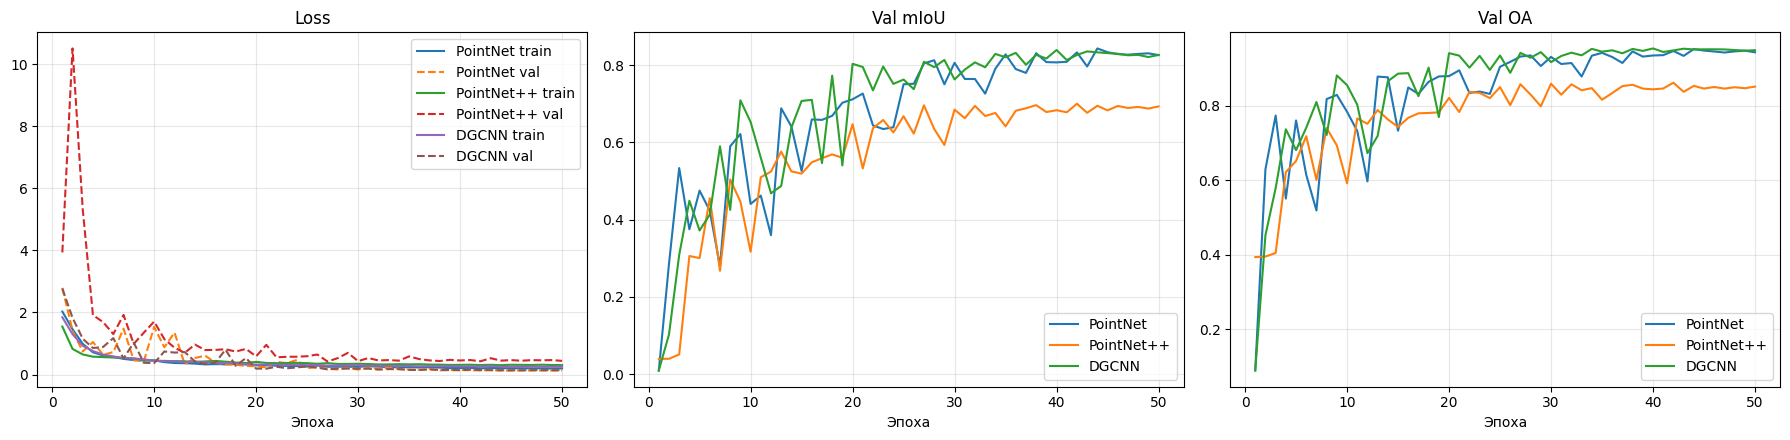

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for name, info in results.items():
    h = info['history']
    epochs = range(1, len(h['train_loss']) + 1)
    axes[0].plot(epochs, h['train_loss'], label=f'{name} train')
    axes[0].plot(epochs, h['val_loss'],   label=f'{name} val', linestyle='--')
    axes[1].plot(epochs, h['val_miou'],    label=name)
    axes[2].plot(epochs, h['val_oa'],      label=name)
axes[0].set_title('Loss');  axes[0].set_xlabel('Эпоха'); axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].set_title('Val mIoU'); axes[1].set_xlabel('Эпоха'); axes[1].grid(alpha=0.3); axes[1].legend()
axes[2].set_title('Val OA');   axes[2].set_xlabel('Эпоха'); axes[2].grid(alpha=0.3); axes[2].legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / '03_training_curves.png', dpi=130, bbox_inches='tight')
plt.show()


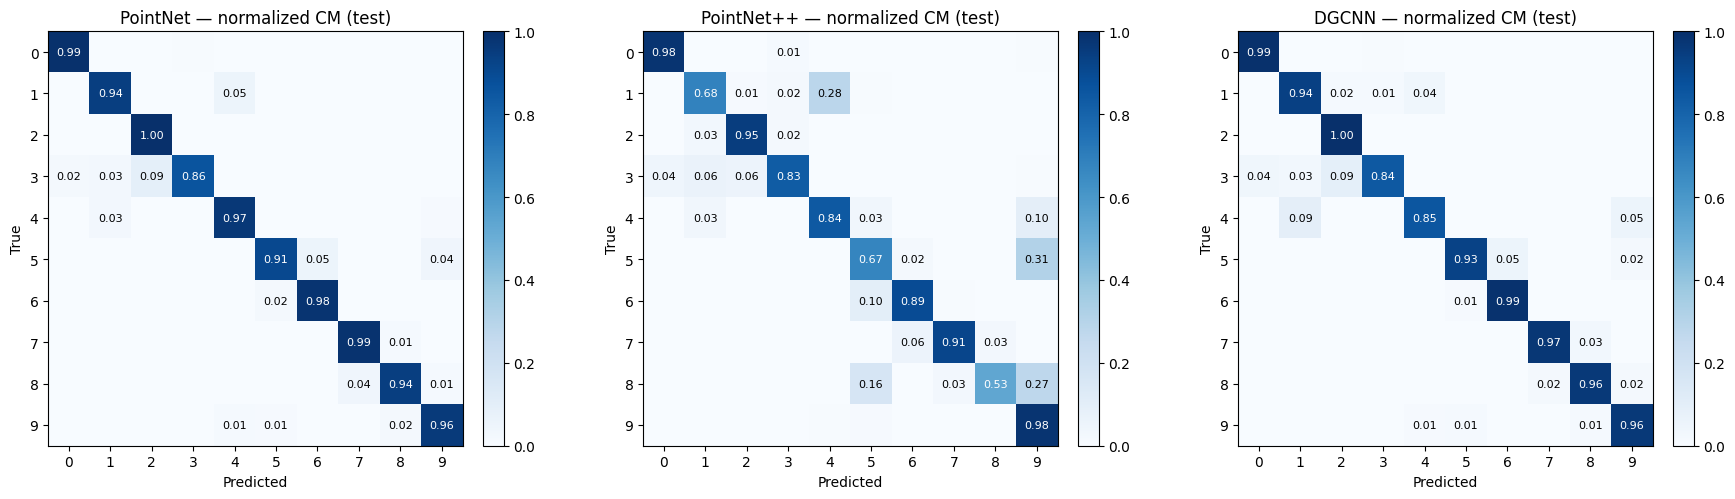

In [ ]:

fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
if len(results) == 1:
    axes = [axes]
for ax, (name, info) in zip(axes, results.items()):
    cm = info['test_metrics']['confusion_matrix']
    cm_norm = cm.astype(np.float64) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{name} — normalized CM (test)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            v = cm_norm[i, j]
            if v > 0.01:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        color='white' if v > 0.5 else 'black', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '04_confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()


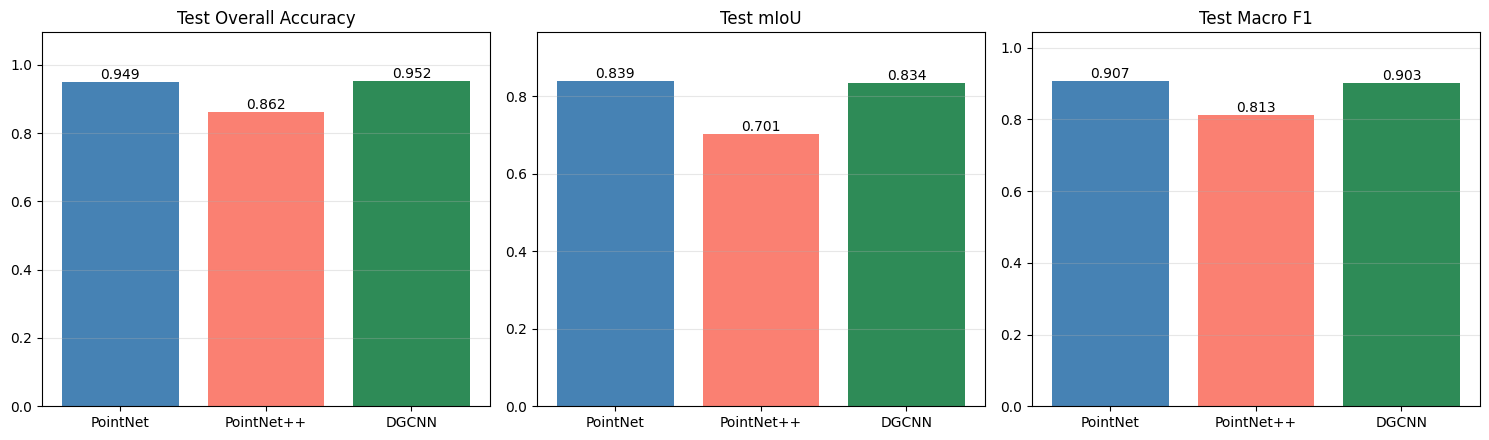

In [ ]:
# Барплоты сравнения моделей
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics_names = [('test_OA', 'Test Overall Accuracy'),
                 ('test_mIoU', 'Test mIoU'),
                 ('test_macro_F1', 'Test Macro F1')]
for ax, (col, title) in zip(axes, metrics_names):
    vals = df_summary[col].values

    ax.bar(df_summary['model'], vals, color=['steelblue', 'salmon', 'seagreen'])
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(title); ax.set_ylim(0, max(vals) * 1.15)
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05_model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


Лучшая модель по test mIoU: PointNet


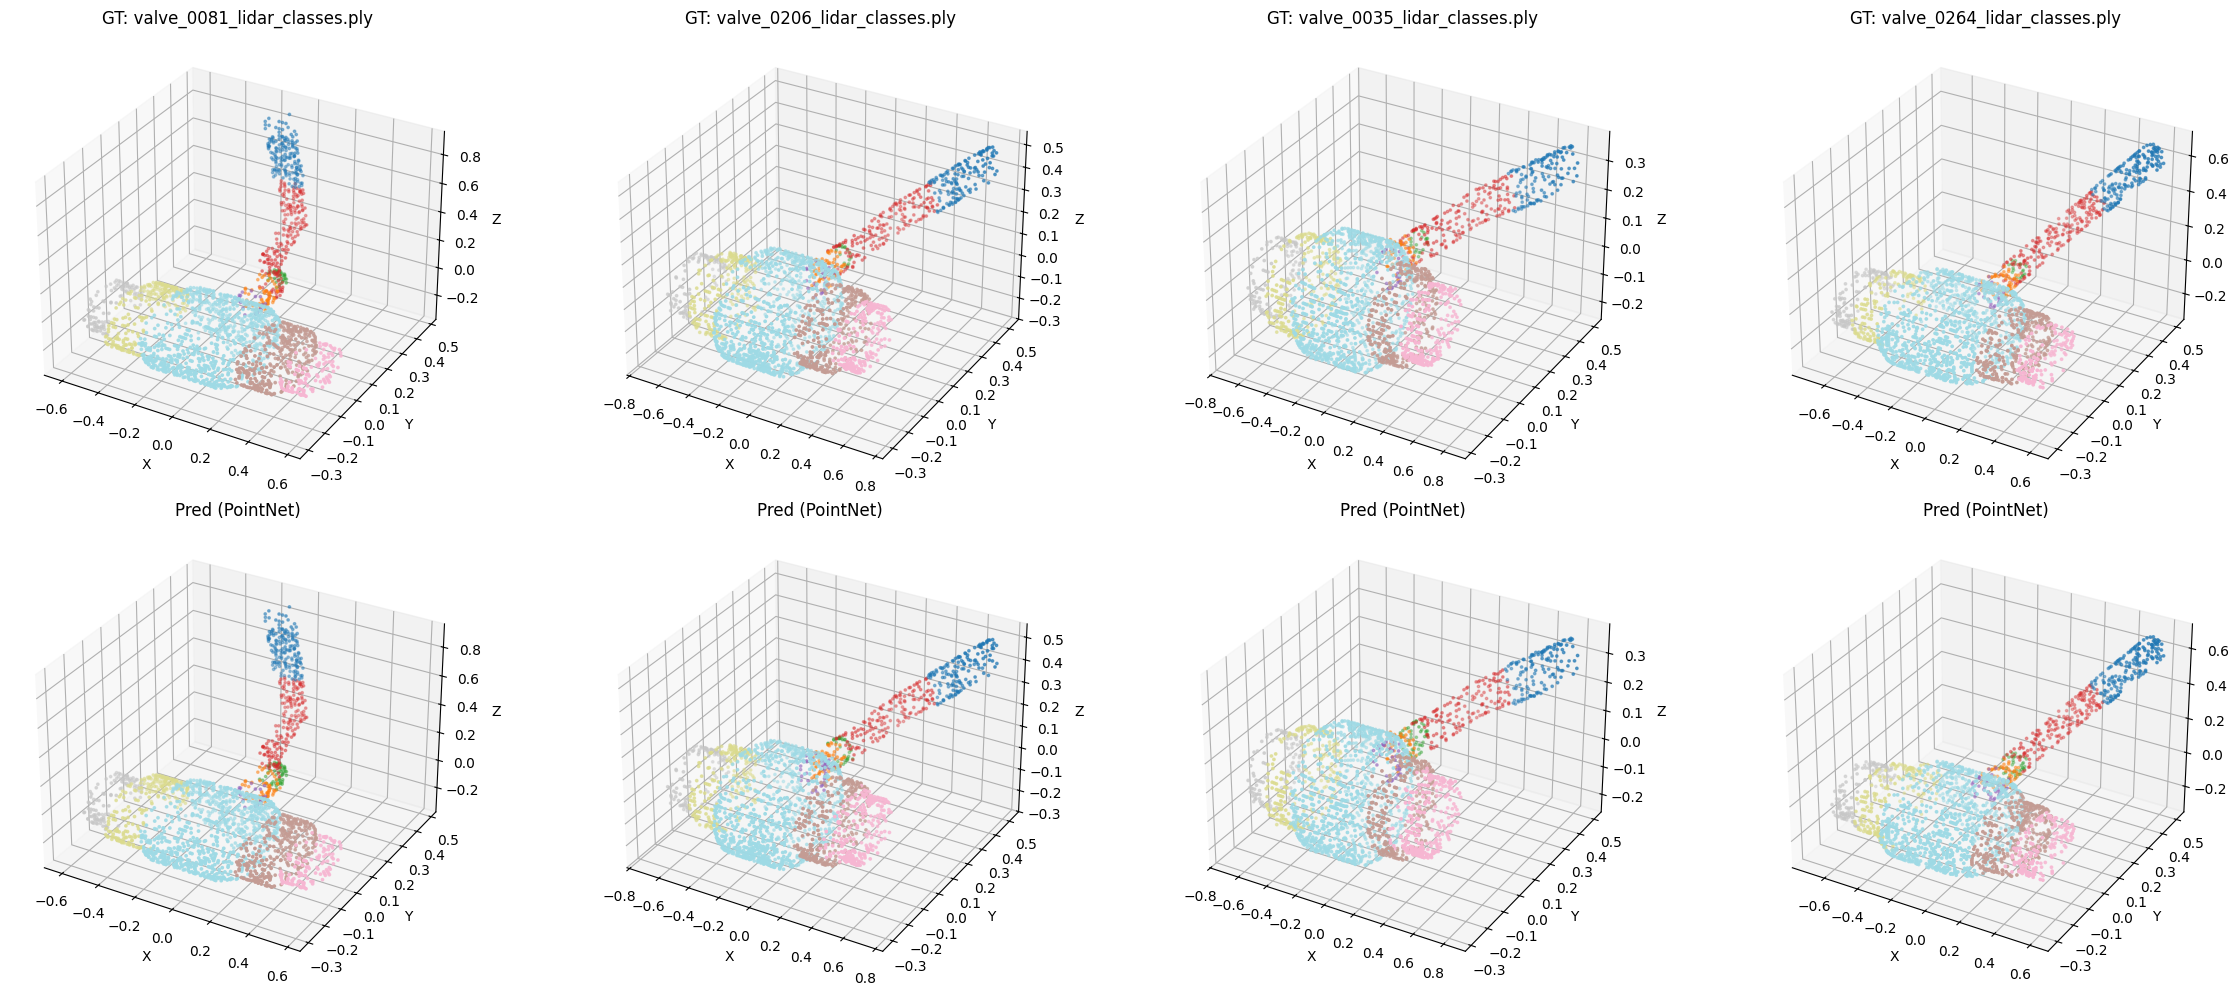

In [ ]:
# Качественная визуализация: предсказания лучшей модели на тестовых примерах
best_name = df_summary.loc[df_summary['test_mIoU'].idxmax(), 'model']
print('Лучшая модель по test mIoU:', best_name)
best_model = trained[best_name].to(device).eval()

# Берём несколько тестовых объектов
n_show = min(4, len(test_files))
sample_paths = test_files[:n_show]

fig = plt.figure(figsize=(6 * n_show, 10))
for i, p in enumerate(sample_paths):
    xyz_full, lab_full = read_ply(p)
    xyz_s, lab_s = sample_points(xyz_full, lab_full, NUM_POINTS)
    xyz_norm = normalize_pc(xyz_s).astype(np.float32)
    with torch.no_grad():
        inp = torch.from_numpy(xyz_norm.T).unsqueeze(0).to(device)
        pred = best_model(inp).argmax(dim=1).cpu().numpy()[0]

    ax = fig.add_subplot(2, n_show, i + 1, projection='3d')
    ax.scatter(xyz_norm[:, 0], xyz_norm[:, 1], xyz_norm[:, 2], c=lab_s, cmap='tab20', s=3)
    ax.set_title(f'GT: {Path(p).name}')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')

    ax = fig.add_subplot(2, n_show, n_show + i + 1, projection='3d')
    ax.scatter(xyz_norm[:, 0], xyz_norm[:, 1], xyz_norm[:, 2], c=pred, cmap='tab20', s=3)
    ax.set_title(f'Pred ({best_name})')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '06_qualitative_predictions.png', dpi=130, bbox_inches='tight')
plt.show()
